In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("crop_yield.csv")

In [3]:
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [4]:
df.shape

(156, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB


In [6]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [7]:
df["Crop"].value_counts()

Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64

In [8]:
df.groupby("Crop")["Yield"].agg(["mean", "min", "max", "std"]).round(2)

,mean,min,max,std
Crop,,,,
"Cocoa, beans",8883.13,5765,13056,1745.03
Oil palm fruit,175804.69,142425,203399,14919.87
"Rice, paddy",32099.67,24686,42550,4789.95
"Rubber, natural",7824.90,5249,10285,1600.26


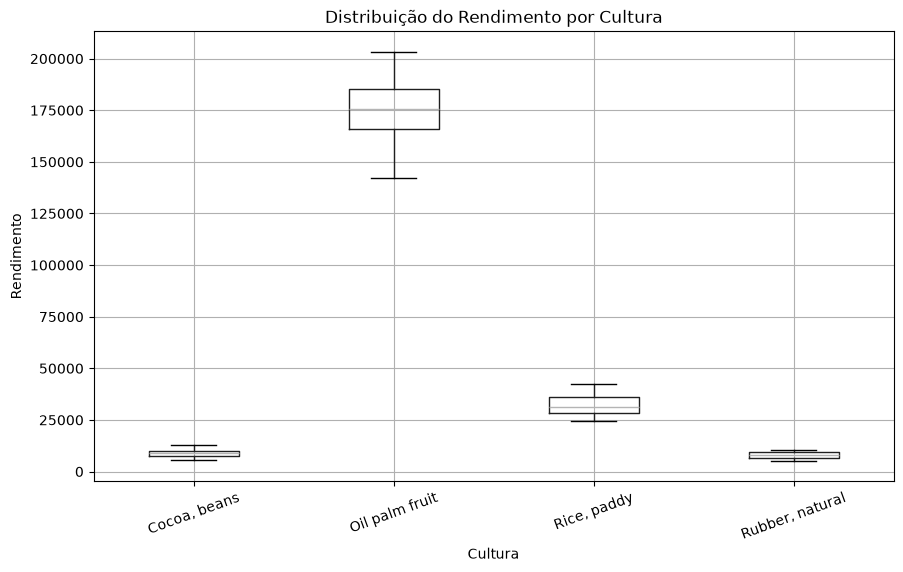

In [9]:
import matplotlib.pyplot as plt

df.boxplot(column="Yield", by="Crop", figsize=(10, 6))

plt.title("Distribuição do Rendimento por Cultura")
plt.suptitle("")
plt.xlabel("Cultura")
plt.ylabel("Rendimento")
plt.xticks(rotation=20)
plt.show()

In [10]:
Q1 = df["Yield"].quantile(0.25)
Q3 = df["Yield"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield"] < limite_inferior) |
    (df["Yield"] > limite_superior)
]

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers:", len(outliers))

outliers[["Crop", "Yield"]]

Limite inferior: -80458.75
Limite superior: 156305.25
Quantidade de outliers: 35


,Crop,Yield
39,Oil palm fruit,169783
40,Oil palm fruit,201436
42,Oil palm fruit,181826
43,Oil palm fruit,178183
44,Oil palm fruit,169781
45,Oil palm fruit,166042
46,Oil palm fruit,165262
47,Oil palm fruit,183004
48,Oil palm fruit,177543
51,Oil palm fruit,172165


In [11]:
def encontrar_outliers(grupo):
    Q1 = grupo["Yield"].quantile(0.25)
    Q3 = grupo["Yield"].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    return grupo[
        (grupo["Yield"] < limite_inferior) |
        (grupo["Yield"] > limite_superior)
    ]

outliers_por_cultura = df.groupby("Crop", group_keys=False).apply(
    encontrar_outliers,
    include_groups=False
)

outliers_por_cultura

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield


In [12]:
df.corr(numeric_only=True).round(2)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Precipitation (mm day-1),1.00,0.49,0.75,-0.08,0.02
Specific Humidity at 2 Meters (g/kg),0.49,1.00,0.44,0.70,0.01
Relative Humidity at 2 Meters (%),0.75,0.44,1.00,-0.34,0.00
Temperature at 2 Meters (C),-0.08,0.70,-0.34,1.00,0.01
Yield,0.02,0.01,0.00,0.01,1.00


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [14]:
scaler = StandardScaler()

In [15]:
df_numeric = df[
    [
        "Precipitation (mm day-1)",
        "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)",
        "Yield"
    ]
]

df_scaled = scaler.fit_transform(df_numeric)


In [17]:
import pandas as pd

pd.DataFrame(resultados, columns=["Número de clusters", "Silhouette Score"])

,Número de clusters,Silhouette Score
0,2,0.316459
1,3,0.333045
2,4,0.362805
3,5,0.374081
4,6,0.355101


In [19]:
df["Cluster"].value_counts().sort_index()

Cluster
0    57
1    13
2    37
3    24
4    25
Name: count, dtype: int64

In [20]:
df.groupby("Cluster")["Yield"].agg(["mean", "min", "max", "std"]).round(2)

,mean,min,max,std
Cluster,,,,
0,16715.33,5249,38763,12224.61
1,65178.00,8800,183004,78777.28
2,43737.14,5765,201436,61335.66
3,36259.54,5571,189896,53149.84
4,178851.68,160862,203399,13149.04


In [21]:
df.groupby("Cluster")[
    [
        "Precipitation (mm day-1)",
        "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)"
    ]
].mean().round(2)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
Cluster,,,,
0,2707.44,18.34,85.56,26.14
1,2397.47,17.65,84.56,25.71
2,2152.20,17.93,83.76,26.13
3,2371.16,18.47,83.85,26.61
4,2634.53,18.33,85.24,26.19


In [22]:
pd.crosstab(df["Cluster"], df["Crop"])

Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Cluster,,,,
0,19,0,19,19
1,3,4,3,3
2,10,7,10,10
3,7,3,7,7
4,0,25,0,0


In [23]:
X = df.drop(columns=["Yield", "Cluster"])
y = df["Yield"]

In [24]:
X = pd.get_dummies(X, columns=["Crop"], drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print("Dados para treinamento:", X_train.shape[0])
print("Dados para teste:", X_test.shape[0])

Dados para treinamento: 124
Dados para teste: 32


In [29]:
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 11.2 , 56977.24,-15248.66,...,166783.33, 22929.91, -1236.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Precipitation (mm day-1)','Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)',...,'Crop_Oil palm fruit', 'Crop_Rice, paddy','Crop_Rubber, natural']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.8e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [30]:
y_pred_linear = modelo_linear.predict(X_test)

y_pred_linear[:10]

array([ 31613.17322375, 178837.90062558,  31324.54031119, 174604.4211162 ,
        36139.60606585,  12086.96791763,  26947.44064114,   5256.5233459 ,
        29422.91932837,   7610.99723635])

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("MAE:", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²:", round(r2_linear, 4))

MAE: 3132.8
RMSE: 4394.17
R²: 0.995


In [32]:
from sklearn.tree import DecisionTreeRegressor

modelo_arvore = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

modelo_arvore.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [33]:
y_pred_arvore = modelo_arvore.predict(X_test)

y_pred_arvore[:10]

array([ 36477.6       , 182696.        ,  25578.25      , 184361.33333333,
        36477.6       ,   8242.15      ,  29855.        ,   7703.58333333,
        30614.        ,   7703.58333333])

In [34]:
mae_arvore = mean_absolute_error(y_test, y_pred_arvore)
rmse_arvore = np.sqrt(mean_squared_error(y_test, y_pred_arvore))
r2_arvore = r2_score(y_test, y_pred_arvore)

print("MAE:", round(mae_arvore, 2))
print("RMSE:", round(rmse_arvore, 2))
print("R²:", round(r2_arvore, 4))

MAE: 2772.09
RMSE: 4857.09
R²: 0.9939


In [35]:
from sklearn.ensemble import RandomForestRegressor

modelo_floresta = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_floresta.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [36]:
y_pred_floresta = modelo_floresta.predict(X_test)

y_pred_floresta[:10]

array([ 29917.68, 175800.34,  26639.64, 184852.59,  34349.4 ,   8713.03,
        30187.13,   6515.61,  28982.61,   7822.16])

In [37]:
mae_floresta = mean_absolute_error(y_test, y_pred_floresta)
rmse_floresta = np.sqrt(mean_squared_error(y_test, y_pred_floresta))
r2_floresta = r2_score(y_test, y_pred_floresta)

print("MAE:", round(mae_floresta, 2))
print("RMSE:", round(rmse_floresta, 2))
print("R²:", round(r2_floresta, 4))

MAE: 2802.37
RMSE: 4881.96
R²: 0.9939


In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler_knn = StandardScaler()

X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

modelo_knn = KNeighborsRegressor(n_neighbors=5)

modelo_knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [39]:
y_pred_knn = modelo_knn.predict(X_test_scaled)

y_pred_knn[:10]

array([ 32754. , 175419. ,  27186.6, 182213.4,  36288.6,   9093.6,
        28572.2,   6876.2,  29153.2,   8256.6])

In [40]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("MAE:", round(mae_knn, 2))
print("RMSE:", round(rmse_knn, 2))
print("R²:", round(r2_knn, 4))

MAE: 2425.86
RMSE: 4606.84
R²: 0.9945


In [41]:
from sklearn.svm import SVR

modelo_svr = SVR(kernel="rbf", C=100, gamma="scale")

modelo_svr.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [42]:
y_pred_svr = modelo_svr.predict(X_test_scaled)

y_pred_svr[:10]

array([13977.56319288, 14222.20348481, 13688.35965884, 14068.29553016,
       13838.80914762, 12436.69289761, 13944.83312256, 11544.4946266 ,
       13978.11224693, 11333.78602048])

In [43]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("MAE:", round(mae_svr, 2))
print("RMSE:", round(rmse_svr, 2))
print("R²:", round(r2_svr, 4))

MAE: 38052.68
RMSE: 70578.07
R²: -0.2842


In [44]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Árvore de Decisão",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE": [
        mae_linear,
        mae_arvore,
        mae_floresta,
        mae_knn,
        mae_svr
    ],
    "RMSE": [
        rmse_linear,
        rmse_arvore,
        rmse_floresta,
        rmse_knn,
        rmse_svr
    ],
    "R²": [
        r2_linear,
        r2_arvore,
        r2_floresta,
        r2_knn,
        r2_svr
    ]
})

resultados_modelos.round(4)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,3132.7964,4394.1658,0.9950
1,Árvore de Decisão,2772.0877,4857.0863,0.9939
2,Random Forest,2802.3709,4881.9624,0.9939
3,KNN,2425.8563,4606.8367,0.9945
4,SVR,38052.6839,70578.0676,-0.2842


In [45]:
y_train_pred_linear = modelo_linear.predict(X_train)

r2_train_linear = r2_score(y_train, y_train_pred_linear)

print("R² no treinamento:", round(r2_train_linear, 4))
print("R² no teste:", round(r2_linear, 4))

R² no treinamento: 0.9872
R² no teste: 0.995


In [46]:
y_train_pred_arvore = modelo_arvore.predict(X_train)

r2_train_arvore = r2_score(y_train, y_train_pred_arvore)

print("R² no treinamento:", round(r2_train_arvore, 4))
print("R² no teste:", round(r2_arvore, 4))

R² no treinamento: 0.9963
R² no teste: 0.9939


In [47]:
y_train_pred_floresta = modelo_floresta.predict(X_train)

r2_train_floresta = r2_score(y_train, y_train_pred_floresta)

print("R² no treinamento:", round(r2_train_floresta, 4))
print("R² no teste:", round(r2_floresta, 4))

R² no treinamento: 0.9982
R² no teste: 0.9939


In [48]:
y_train_pred_knn = modelo_knn.predict(X_train_scaled)

r2_train_knn = r2_score(y_train, y_train_pred_knn)

print("R² no treinamento:", round(r2_train_knn, 4))
print("R² no teste:", round(r2_knn, 4))


R² no treinamento: 0.9779
R² no teste: 0.9945


In [49]:
y_train_pred_svr = modelo_svr.predict(X_train_scaled)

r2_train_svr = r2_score(y_train, y_train_pred_svr)

print("R² no treinamento:", round(r2_train_svr, 4))
print("R² no teste:", round(r2_svr, 4))

R² no treinamento: -0.3784
R² no teste: -0.2842


In [50]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

In [51]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [52]:
resultado_linear_cv = cross_validate(
    modelo_linear,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE médio:", round(-resultado_linear_cv["test_MAE"].mean(), 2))
print("RMSE médio:", round(-resultado_linear_cv["test_RMSE"].mean(), 2))
print("R² médio:", round(resultado_linear_cv["test_R2"].mean(), 4))

MAE médio: 5087.74
RMSE médio: 7874.35
R² médio: 0.987


In [53]:
resultado_arvore_cv = cross_validate(
    modelo_arvore,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE médio:", round(-resultado_arvore_cv["test_MAE"].mean(), 2))
print("RMSE médio:", round(-resultado_arvore_cv["test_RMSE"].mean(), 2))
print("R² médio:", round(resultado_arvore_cv["test_R2"].mean(), 4))

MAE médio: 4988.17
RMSE médio: 8585.0
R² médio: 0.9843


In [54]:
resultado_floresta_cv = cross_validate(
    modelo_floresta,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE médio:", round(-resultado_floresta_cv["test_MAE"].mean(), 2))
print("RMSE médio:", round(-resultado_floresta_cv["test_RMSE"].mean(), 2))
print("R² médio:", round(resultado_floresta_cv["test_R2"].mean(), 4))

MAE médio: 4291.63
RMSE médio: 7548.43
R² médio: 0.9878


In [55]:
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsRegressor(n_neighbors=5))
])

resultado_knn_cv = cross_validate(
    pipeline_knn,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE médio:", round(-resultado_knn_cv["test_MAE"].mean(), 2))
print("RMSE médio:", round(-resultado_knn_cv["test_RMSE"].mean(), 2))
print("R² médio:", round(resultado_knn_cv["test_R2"].mean(), 4))

MAE médio: 5413.41
RMSE médio: 10249.49
R² médio: 0.9774


In [56]:
pipeline_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", SVR(kernel="rbf", C=100, gamma="scale"))
])

resultado_svr_cv = cross_validate(
    pipeline_svr,
    X,
    y,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE médio:", round(-resultado_svr_cv["test_MAE"].mean(), 2))
print("RMSE médio:", round(-resultado_svr_cv["test_RMSE"].mean(), 2))
print("R² médio:", round(resultado_svr_cv["test_R2"].mean(), 4))

MAE médio: 48092.2
RMSE médio: 79664.62
R² médio: -0.3082


In [57]:
resultados_cv = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Árvore de Decisão",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE médio": [
        5087.74,
        4988.17,
        4291.63,
        5413.41,
        48092.20
    ],
    "RMSE médio": [
        7874.35,
        8585.00,
        7548.43,
        10249.49,
        79664.62
    ],
    "R² médio": [
        0.9870,
        0.9843,
        0.9878,
        0.9774,
        -0.3082
    ]
})

resultados_cv

,Modelo,MAE médio,RMSE médio,R² médio
0,Regressão Linear,5087.74,7874.35,0.9870
1,Árvore de Decisão,4988.17,8585.00,0.9843
2,Random Forest,4291.63,7548.43,0.9878
3,KNN,5413.41,10249.49,0.9774
4,SVR,48092.20,79664.62,-0.3082


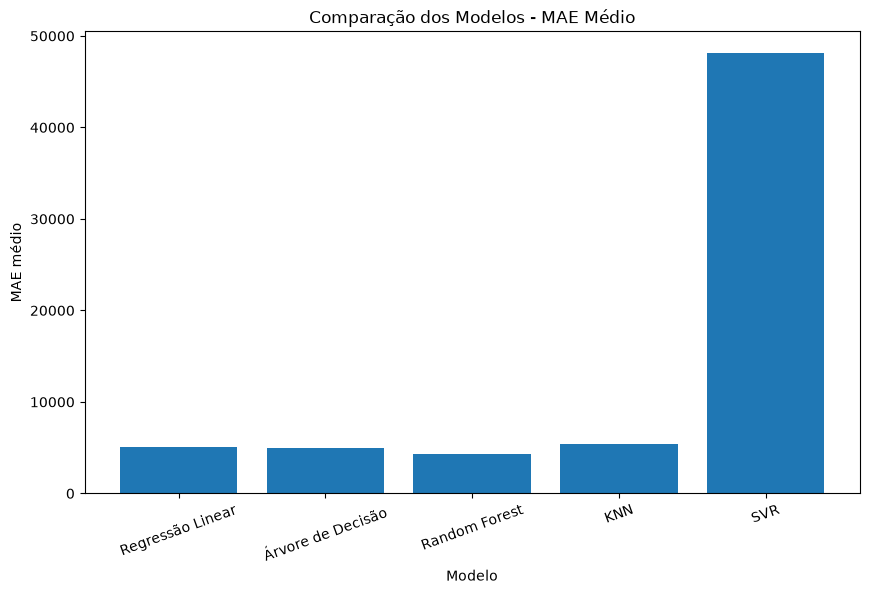

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(resultados_cv["Modelo"], resultados_cv["MAE médio"])

plt.title("Comparação dos Modelos - MAE Médio")
plt.xlabel("Modelo")
plt.ylabel("MAE médio")
plt.xticks(rotation=20)

plt.show()

In [59]:
resultados_cv

,Modelo,MAE médio,RMSE médio,R² médio
0,Regressão Linear,5087.74,7874.35,0.9870
1,Árvore de Decisão,4988.17,8585.00,0.9843
2,Random Forest,4291.63,7548.43,0.9878
3,KNN,5413.41,10249.49,0.9774
4,SVR,48092.20,79664.62,-0.3082


## Conclusão da Modelagem Preditiva

Foram desenvolvidos e avaliados cinco modelos de regressão para prever o rendimento das culturas: Regressão Linear, Árvore de Decisão, Random Forest, KNN e SVR.

Para tornar a avaliação mais robusta, foi utilizada validação cruzada com 5 folds, considerando as métricas MAE, RMSE e R².

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho geral, com MAE médio de 4.291,63, RMSE médio de 7.548,43 e R² médio de 0,9878. Dessa forma, o Random Forest foi selecionado como o modelo de melhor desempenho para este conjunto de dados.

A Regressão Linear também apresentou resultados próximos aos do Random Forest. A Árvore de Decisão e o KNN apresentaram desempenho satisfatório, porém inferior. Já o SVR apresentou desempenho significativamente inferior aos demais modelos, com R² médio negativo.

Os resultados indicam que os modelos conseguem realizar boas previsões de rendimento neste conjunto de dados. Entretanto, os resultados devem ser interpretados com cautela, pois o conjunto de dados possui apenas 156 registros e apresenta diferenças bastante acentuadas de rendimento entre as culturas.

## Pontos Fortes e Limitações

### Pontos Fortes

- Foram avaliados cinco algoritmos de regressão diferentes.
- Foram utilizadas métricas complementares: MAE, RMSE e R².
- A validação cruzada com 5 folds tornou a avaliação mais robusta.
- O Random Forest apresentou o melhor desempenho geral entre os modelos avaliados.
- A análise de clusterização permitiu identificar diferentes padrões de rendimento e condições ambientais.

### Limitações

- O conjunto de dados possui apenas 156 registros, o que limita a capacidade de generalização dos modelos.
- Os rendimentos apresentam diferenças muito grandes entre as culturas, o que influencia fortemente os resultados.
- A análise de clusterização utilizou o rendimento juntamente com as variáveis climáticas, portanto os clusters não devem ser interpretados como evidência de relação causal entre clima e produtividade.
- O conjunto de dados possui apenas quatro variáveis climáticas, podendo existir outros fatores importantes para explicar o rendimento agrícola.
- Os valores de rendimento devem ser interpretados de acordo com a unidade e escala fornecidas na base de dados.

## Conclusão Geral

A análise realizada permitiu explorar os dados de diferentes formas, combinando técnicas de aprendizado de máquina supervisionado e não supervisionado.

Na análise exploratória, foi possível observar diferenças significativas de rendimento entre as quatro culturas analisadas. A clusterização com K-Means permitiu identificar grupos com diferentes padrões de condições ambientais e rendimento.

Na etapa de modelagem preditiva, foram avaliados cinco algoritmos de regressão. Após a validação cruzada com 5 folds, o Random Forest apresentou o melhor desempenho geral, obtendo MAE médio de 4.291,63, RMSE médio de 7.548,43 e R² médio de 0,9878.

Os resultados mostram que o aprendizado de máquina pode ser utilizado como uma ferramenta de apoio à análise e previsão de rendimento agrícola. Entretanto, os resultados devem ser interpretados considerando as limitações da base de dados, principalmente seu tamanho reduzido, as diferenças de escala entre as culturas e a quantidade limitada de variáveis disponíveis.

Como melhoria futura, seria interessante utilizar uma base de dados maior e incluir outras informações relevantes, como características do solo, fertilização, irrigação, localização, histórico climático e práticas agrícolas.

## Previsão de Rendimento com o Modelo Final

Após a avaliação dos cinco modelos, o Random Forest foi selecionado como o modelo de melhor desempenho. Nesta etapa, o modelo será utilizado para estimar o rendimento de uma nova condição de cultivo, considerando a cultura e as variáveis climáticas.

In [61]:
nova_condicao = pd.DataFrame({
    "Precipitation (mm day-1)": [2500],
    "Specific Humidity at 2 Meters (g/kg)": [18.2],
    "Relative Humidity at 2 Meters (%)": [84.7],
    "Temperature at 2 Meters (C)": [26.2],
    "Crop_Oil palm fruit": [0],
    "Crop_Rice, paddy": [1],
    "Crop_Rubber, natural": [0]
})

nova_condicao

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2500,18.2,84.7,26.2,0,1,0


In [62]:
previsao = modelo_floresta.predict(nova_condicao)

print("Rendimento previsto:", round(previsao[0], 2))

Rendimento previsto: 28760.0


### Interpretação da Previsão

Para uma nova condição de cultivo de Rice, paddy, com precipitação de 2500 mm day-1, umidade específica de 18,2 g/kg, umidade relativa de 84,7% e temperatura de 26,2 °C, o modelo Random Forest estimou um rendimento de 28.760.

Essa previsão demonstra uma aplicação prática do modelo desenvolvido, permitindo estimar o rendimento esperado de uma cultura a partir das condições fornecidas. O resultado deve ser interpretado considerando a unidade e a escala dos valores presentes na base de dados.